In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
# import matplotlib
# matplotlib.use('tkagg')

Load temperature data

In [2]:
df_temp_raw = pd.read_csv("seoul_temperature_19042024.csv", skiprows=11, encoding="cp949")
df_temp_raw.head(3)

,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,108,서울,1907-10,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24
1,108,서울,1907-11,5.3,10.2,21.3,1907-11-01,0.6,-8.9,1907-11-30
2,108,서울,1907-12,-3.9,0.8,9.0,1907-12-13,-8.7,-20.1,1907-12-23


In [3]:
df_temp_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "avg_temp",
    "avg_max_temp",
    "max_temp",
    "date_of_max_temp",
    "avg_min_temp",
    "min_temp",
    "date_of_min_temp"
]

# convert date into datetime formate
df_temp_raw["avg_temp_diff"] = df_temp_raw["max_temp"] - df_temp_raw["min_temp"]
df_temp_raw["year_month"] = pd.to_datetime(df_temp_raw["year_month"], format="%Y-%m")
df_temp_raw["date_of_max_temp"] = pd.to_datetime(df_temp_raw["date_of_max_temp"])
df_temp_raw["date_of_min_temp"] = pd.to_datetime(df_temp_raw["date_of_min_temp"])
df_temp_raw['month'] = df_temp_raw['year_month'].dt.month
df_temp_raw['year'] = df_temp_raw['year_month'].dt.year
df_temp_raw['t'] = np.arange(len(df_temp_raw))

# load cleaned df
df_temp_raw.head(3)

,station_id,location,year_month,avg_temp,avg_max_temp,max_temp,date_of_max_temp,avg_min_temp,min_temp,date_of_min_temp,avg_temp_diff,month,year,t
0,108,서울,1907-10-01,13.9,20.2,25.4,1907-10-05,8.3,3.3,1907-10-24,22.1,10,1907,0
1,108,서울,1907-11-01,5.3,10.2,21.3,1907-11-01,0.6,-8.9,1907-11-30,30.2,11,1907,1
2,108,서울,1907-12-01,-3.9,0.8,9.0,1907-12-13,-8.7,-20.1,1907-12-23,29.1,12,1907,2


Load humidity data

In [4]:
df_humidity_raw = pd.read_csv("seoul_humidity_19042024.csv", skiprows=11, encoding="cp949")
df_humidity_raw.head(3)

,\t\t지점번호,지점명,일시,평균습도(%rh),최저습도(%rh)
0,108,서울,1907-10,76.0,NaN
1,108,서울,1907-11,77.0,NaN
2,108,서울,1907-12,68.0,NaN


In [5]:
df_humidity_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "avg_humidity",
    "min_humidity"
]

# convert date into datetime formate
df_humidity_raw["year_month"] = pd.to_datetime(df_humidity_raw["year_month"], format="%Y-%m")
df_humidity_raw['month'] = df_humidity_raw['year_month'].dt.month
df_humidity_raw['year'] = df_humidity_raw['year_month'].dt.year
df_humidity_raw['t'] = np.arange(len(df_humidity_raw))

# load cleaned df
df_humidity_raw.head(3)

,station_id,location,year_month,avg_humidity,min_humidity,month,year,t
0,108,서울,1907-10-01,76.0,NaN,10,1907,0
1,108,서울,1907-11-01,77.0,NaN,11,1907,1
2,108,서울,1907-12-01,68.0,NaN,12,1907,2


Load Rainfall data

In [6]:
df_rainfall_raw = pd.read_csv("seoul_rainfall_19042024.csv", skiprows=11, encoding="cp949")
df_rainfall_raw.head(3)

,\t지점번호,지점명,일시,강수량(mm),일최다강수량(mm),일최다강수량일자,1시간최다강수량(mm),1시간최다강수량일자,Unnamed: 8
0,108,서울,1907-10,47.0,24.8,1907-10-06,NaN,NaN,NaN
1,108,서울,1907-11,54.4,19.3,1907-11-11,NaN,NaN,NaN
2,108,서울,1907-12,25.2,9.6,1907-12-20,NaN,NaN,NaN


In [7]:
df_rainfall_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "rainfall_mm",
    "max_rainfall_day_mm",
    "max_rainfall_date",
    "max_rainfall_hour",
    "max_rainfall_hour_date",
    "empty"
]

# convert date into datetime formate
df_rainfall_raw["year_month"] = pd.to_datetime(df_rainfall_raw["year_month"], format="%Y-%m")
df_rainfall_raw["max_rainfall_date"] = pd.to_datetime(df_rainfall_raw["max_rainfall_date"])
df_rainfall_raw["max_rainfall_hour_date"] = pd.to_datetime(df_rainfall_raw["max_rainfall_hour_date"])
df_rainfall_raw['month'] = df_rainfall_raw['year_month'].dt.month
df_rainfall_raw['year'] = df_rainfall_raw['year_month'].dt.year
df_rainfall_raw['t'] = np.arange(len(df_rainfall_raw))
df_rainfall_raw = df_rainfall_raw.drop(columns=["empty"])

# load cleaned df
df_rainfall_raw.head(3)

,station_id,location,year_month,rainfall_mm,max_rainfall_day_mm,max_rainfall_date,max_rainfall_hour,max_rainfall_hour_date,month,year,t
0,108,서울,1907-10-01,47.0,24.8,1907-10-06,NaN,NaT,10,1907,0
1,108,서울,1907-11-01,54.4,19.3,1907-11-11,NaN,NaT,11,1907,1
2,108,서울,1907-12-01,25.2,9.6,1907-12-20,NaN,NaT,12,1907,2


In [8]:
df_sunexposure_raw = pd.read_csv("seoul_sunexposure_19042024.csv", skiprows=11, encoding="cp949")
df_sunexposure_raw.head(3)


,\t\t지점번호,지점명,일시,일조합(hr),일조율(%),일사합(MJ/m2)
0,108,서울,1907-10,241.3,NaN,NaN
1,108,서울,1907-11,175.3,NaN,NaN
2,108,서울,1907-12,191.9,NaN,NaN


In [9]:
df_sunexposure_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "sun_exposure_hr",
    "sun_exposure_percent",
    "sun_exposure_per_area"
]

# convert date into datetime formate
df_sunexposure_raw["year_month"] = pd.to_datetime(df_sunexposure_raw["year_month"], format="%Y-%m")
df_sunexposure_raw['month'] = df_sunexposure_raw['year_month'].dt.month
df_sunexposure_raw['year'] = df_sunexposure_raw['year_month'].dt.year
df_sunexposure_raw['t'] = np.arange(len(df_sunexposure_raw))

# load cleaned df
df_sunexposure_raw.head(3)

,station_id,location,year_month,sun_exposure_hr,sun_exposure_percent,sun_exposure_per_area,month,year,t
0,108,서울,1907-10-01,241.3,NaN,NaN,10,1907,0
1,108,서울,1907-11-01,175.3,NaN,NaN,11,1907,1
2,108,서울,1907-12-01,191.9,NaN,NaN,12,1907,2


In [10]:
df_windspeed_raw = pd.read_csv("seoul_windspeed_19042024.csv", skiprows=11, encoding="cp949")
df_windspeed_raw.head(3)

,\t\t지점번호,지점명,일시,평균풍속(m/s),최대풍속(m/s),최대풍속풍향(deg),\t최대풍속일자,최대순간풍속(m/s),최대순간풍속풍향(deg),\t최대순간풍속일자,\t
0,108,서울,1907-10,2.2,8.5,320.0,1907-10-23,NaN,NaN,NaN,NaN
1,108,서울,1907-11,2.7,14.7,320.0,1907-11-27,NaN,NaN,NaN,NaN
2,108,서울,1907-12,3.0,16.0,320.0,1907-12-20,NaN,NaN,NaN,NaN


In [11]:
df_windspeed_raw.columns = [
    "station_id",
    "location",
    "year_month",
    "avg_wind_speed_ms",
    "max_wind_speed_ms",
    "max_windspeed_direction",
    "max_wind_speed_date",
    "max_wind_temporal_speed",
    "max_wind_temporal_direction",
    "max_wind_temporal_speed_date",
    "empty"
]

# convert date into datetime formate
df_windspeed_raw["year_month"] = pd.to_datetime(df_windspeed_raw["year_month"], format="%Y-%m")
df_windspeed_raw["max_wind_speed_date"] = pd.to_datetime(df_windspeed_raw["max_wind_speed_date"])
df_windspeed_raw["max_wind_temporal_speed_date"] = pd.to_datetime(df_windspeed_raw["max_wind_temporal_speed_date"])
df_windspeed_raw['month'] = df_windspeed_raw['year_month'].dt.month
df_windspeed_raw['year'] = df_windspeed_raw['year_month'].dt.year
df_windspeed_raw['t'] = np.arange(len(df_windspeed_raw))
df_windspeed_raw = df_windspeed_raw.drop(columns=["empty"])

# load cleaned df
df_windspeed_raw.head(3)

,station_id,location,year_month,avg_wind_speed_ms,max_wind_speed_ms,max_windspeed_direction,max_wind_speed_date,max_wind_temporal_speed,max_wind_temporal_direction,max_wind_temporal_speed_date,month,year,t
0,108,서울,1907-10-01,2.2,8.5,320.0,1907-10-23,NaN,NaN,NaT,10,1907,0
1,108,서울,1907-11-01,2.7,14.7,320.0,1907-11-27,NaN,NaN,NaT,11,1907,1
2,108,서울,1907-12-01,3.0,16.0,320.0,1907-12-20,NaN,NaN,NaT,12,1907,2


Combine climate data

In [12]:
dfs_climate = [df_temp_raw, df_humidity_raw, df_sunexposure_raw, df_windspeed_raw, df_rainfall_raw]
for i in range(len(dfs_climate)):
    dfs_climate[i] = dfs_climate[i].drop(columns=["station_id", "location", "t"])
df_temp_raw, df_humidity_raw, df_sunexposure_raw, df_windspeed_raw, df_rainfall_raw = dfs_climate
df_windspeed_raw.head(3)


,year_month,avg_wind_speed_ms,max_wind_speed_ms,max_windspeed_direction,max_wind_speed_date,max_wind_temporal_speed,max_wind_temporal_direction,max_wind_temporal_speed_date,month,year
0,1907-10-01,2.2,8.5,320.0,1907-10-23,NaN,NaN,NaT,10,1907
1,1907-11-01,2.7,14.7,320.0,1907-11-27,NaN,NaN,NaT,11,1907
2,1907-12-01,3.0,16.0,320.0,1907-12-20,NaN,NaN,NaT,12,1907


In [13]:
# merge climate data
df_climate_merged = pd.merge(df_temp_raw, df_humidity_raw, on=['year', 'month', "year_month"], how='inner')
df_climate_merged = pd.merge(df_climate_merged, df_sunexposure_raw, on=['year', 'month', "year_month"], how='inner')
df_climate_merged = pd.merge(df_climate_merged, df_windspeed_raw, on=['year', 'month', "year_month"], how='inner')
df_climate_merged = pd.merge(df_climate_merged, df_rainfall_raw, on=['year', 'month', "year_month"], how='inner')

In [14]:
df_climate_merged.columns

Index(['year_month', 'avg_temp', 'avg_max_temp', 'max_temp',
       'date_of_max_temp', 'avg_min_temp', 'min_temp', 'date_of_min_temp',
       'avg_temp_diff', 'month', 'year', 'avg_humidity', 'min_humidity',
       'sun_exposure_hr', 'sun_exposure_percent', 'sun_exposure_per_area',
       'avg_wind_speed_ms', 'max_wind_speed_ms', 'max_windspeed_direction',
       'max_wind_speed_date', 'max_wind_temporal_speed',
       'max_wind_temporal_direction', 'max_wind_temporal_speed_date',
       'rainfall_mm', 'max_rainfall_day_mm', 'max_rainfall_date',
       'max_rainfall_hour', 'max_rainfall_hour_date'],
      dtype='object')

In [15]:
columns_to_use = ["year", "month", "year_month", "avg_temp", "avg_temp_diff", "avg_humidity", "sun_exposure_percent", "avg_wind_speed_ms", "rainfall_mm"]
df_climate_merged = df_climate_merged[columns_to_use]
start_date = "2017-01-01"
end_date = "2019-12-31"
df_climate_merged = df_climate_merged[(df_climate_merged["year_month"] >= start_date) & (df_climate_merged["year_month"] <= end_date)]
df_climate_merged.head(3)

,year,month,year_month,avg_temp,avg_temp_diff,avg_humidity,sun_exposure_percent,avg_wind_speed_ms,rainfall_mm
1297,2017,1,2017-01-01,-1.8,24.0,55.0,67.97,2.3,14.9
1298,2017,2,2017-02-01,-0.2,21.6,54.0,69.31,2.4,11.1
1299,2017,3,2017-03-01,6.3,24.2,48.0,68.73,2.4,7.9


Load Crime Data

In [16]:
# tranlstion of crime types
translation_df = pd.read_csv("crime_translation.csv")
translation_dict = dict(zip(translation_df["Korean"], translation_df["English"]))

# load 3 files (for each year) and combine
def process_file(file_path, year):
    df = pd.read_csv(file_path, index_col=0, encoding="cp949")
    df = df.T # Transpose
    # remove korean from months and format as int '1월' -> 1
    df.index = df.index.str.replace("월", "").astype(int)
    df['year'] = year
    df['month'] = df.index
    return df.reset_index(drop=True)

crime_dfs = []
for year in [2017, 2018, 2019]:
    file_name = f"crime_{year}.csv"
    df = process_file(file_name, year)
    crime_dfs.append(df)

df_crime_years_combined = pd.concat(crime_dfs, ignore_index=True)
df_crime_years_combined.rename(columns=translation_dict, inplace=True)
# print(df_crime_years_combined.head(14))
# print(df_crime_years_combined.shape)

crime_cols = df_crime_years_combined.columns.difference(['year', 'month'])
crime_sums = df_crime_years_combined[crime_cols].sum()

# only takes crime types with 20000 or higher sum
filtered_columns = crime_sums[crime_sums >= 20000].index
df_crime_years_combined = df_crime_years_combined[['year', 'month'] + list(filtered_columns)]

df_crime_years_combined.to_csv("combined_filtered_crime_data.csv", index=False)

In [17]:
df_crime = pd.read_csv("combined_filtered_crime_data.csv")
df_crime.head(10)

,year,month,Assault,Automobile Damage Compensation Guarantee Act,Bodily Injury,Copyright Act,Defamation,Destruction of Property,Documents,Electronic Financial Transactions Act,...,Retirement Benefit Guarantee Act,Road Traffic Act,Road Traffic Act (Drunk Driving),Road Traffic Act (Failure to Act After Accident),Road Traffic Act (Unlicensed Driving),Sexual Violence,Special Act on Traffic Accident Handling,Theft,Threat,Youth Protection Act
0,2017,1,13068,2960,3863,1783,1918,4276,1549,514,...,1403,1322,11131,6786,2614,1951,15025,14465,1187,695
1,2017,2,11636,3339,3491,1167,1722,3869,1148,514,...,936,1431,12590,6267,4709,1937,12949,12829,1159,670
2,2017,3,13768,4533,4053,1245,1897,4597,1362,585,...,1316,2162,16782,6959,5852,2699,14792,15376,1388,578
3,2017,4,13714,4230,4206,1014,2178,4712,1392,556,...,1197,2047,18094,7157,5373,2887,15369,15402,1402,678
4,2017,5,14545,4308,4443,963,2340,5045,1286,481,...,1061,1764,16788,7231,5337,3307,15901,17096,1436,836
5,2017,6,14652,3880,4513,1082,2363,5107,1182,462,...,1207,1433,16213,2631,4731,3458,15432,17061,1404,769
6,2017,7,15178,3641,4693,1083,2546,5374,1346,458,...,1316,1354,16330,2090,4218,3572,15635,16760,1478,814
7,2017,8,15452,3735,4411,1060,2308,5295,1338,483,...,1164,1317,16086,1799,4463,3580,15942,16698,1626,765
8,2017,9,15380,3640,4283,989,2588,5224,1125,395,...,1130,1228,16199,1581,3872,3217,16961,16664,1477,900
9,2017,10,14419,3468,4024,976,2140,4931,1168,483,...,1085,1076,13752,1500,2454,2531,15958,15851,1354,908


In [18]:
df_crime.shape

(36, 34)

In [19]:
summary = df_crime.groupby(['year', 'month']).sum()
crime_summary = df_crime.drop(columns=['year', 'month']).describe()
crime_summary

,Assault,Automobile Damage Compensation Guarantee Act,Bodily Injury,Copyright Act,Defamation,Destruction of Property,Documents,Electronic Financial Transactions Act,Embezzlement,Food Sanitation Act,...,Retirement Benefit Guarantee Act,Road Traffic Act,Road Traffic Act (Drunk Driving),Road Traffic Act (Failure to Act After Accident),Road Traffic Act (Unlicensed Driving),Sexual Violence,Special Act on Traffic Accident Handling,Theft,Threat,Youth Protection Act
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,13664.250000,2648.916667,3704.111111,900.611111,2356.083333,4778.166667,1256.333333,639.277778,4738.916667,644.805556,...,1161.694444,1278.527778,11850.916667,2158.555556,2642.083333,2693.250000,16031.416667,15262.277778,1539.777778,708.277778
std,1291.598796,801.962072,442.862751,254.106758,303.687186,532.845488,140.292551,128.741959,499.802097,108.364680,...,123.700980,276.852048,2989.531653,2024.843125,1269.646506,570.348133,1297.989134,1499.108737,305.337669,104.614834
min,10893.000000,1634.000000,2813.000000,550.000000,1722.000000,3818.000000,1069.000000,395.000000,3580.000000,426.000000,...,854.000000,847.000000,7060.000000,880.000000,1264.000000,1798.000000,12949.000000,12504.000000,1032.000000,513.000000
25%,12336.000000,2056.250000,3452.500000,730.500000,2138.500000,4265.000000,1147.000000,532.000000,4529.250000,561.250000,...,1081.250000,1097.750000,9417.250000,1093.500000,1832.000000,2083.000000,15373.500000,14207.000000,1379.500000,630.250000
50%,13873.500000,2385.500000,3644.000000,850.500000,2425.000000,4806.000000,1233.000000,644.000000,4684.500000,647.000000,...,1152.000000,1247.500000,11380.000000,1254.500000,2259.000000,2735.000000,16020.000000,15573.000000,1468.000000,718.500000
75%,14675.250000,3054.750000,3923.250000,1025.500000,2556.500000,5196.750000,1340.000000,738.500000,5005.250000,741.000000,...,1256.750000,1362.000000,13554.000000,1813.250000,2557.750000,3208.500000,16789.750000,16531.250000,1659.000000,766.000000
max,15452.000000,4533.000000,4693.000000,1783.000000,2997.000000,5668.000000,1599.000000,912.000000,5604.000000,821.000000,...,1403.000000,2162.000000,18094.000000,7231.000000,5852.000000,3580.000000,18768.000000,17333.000000,2210.000000,908.000000


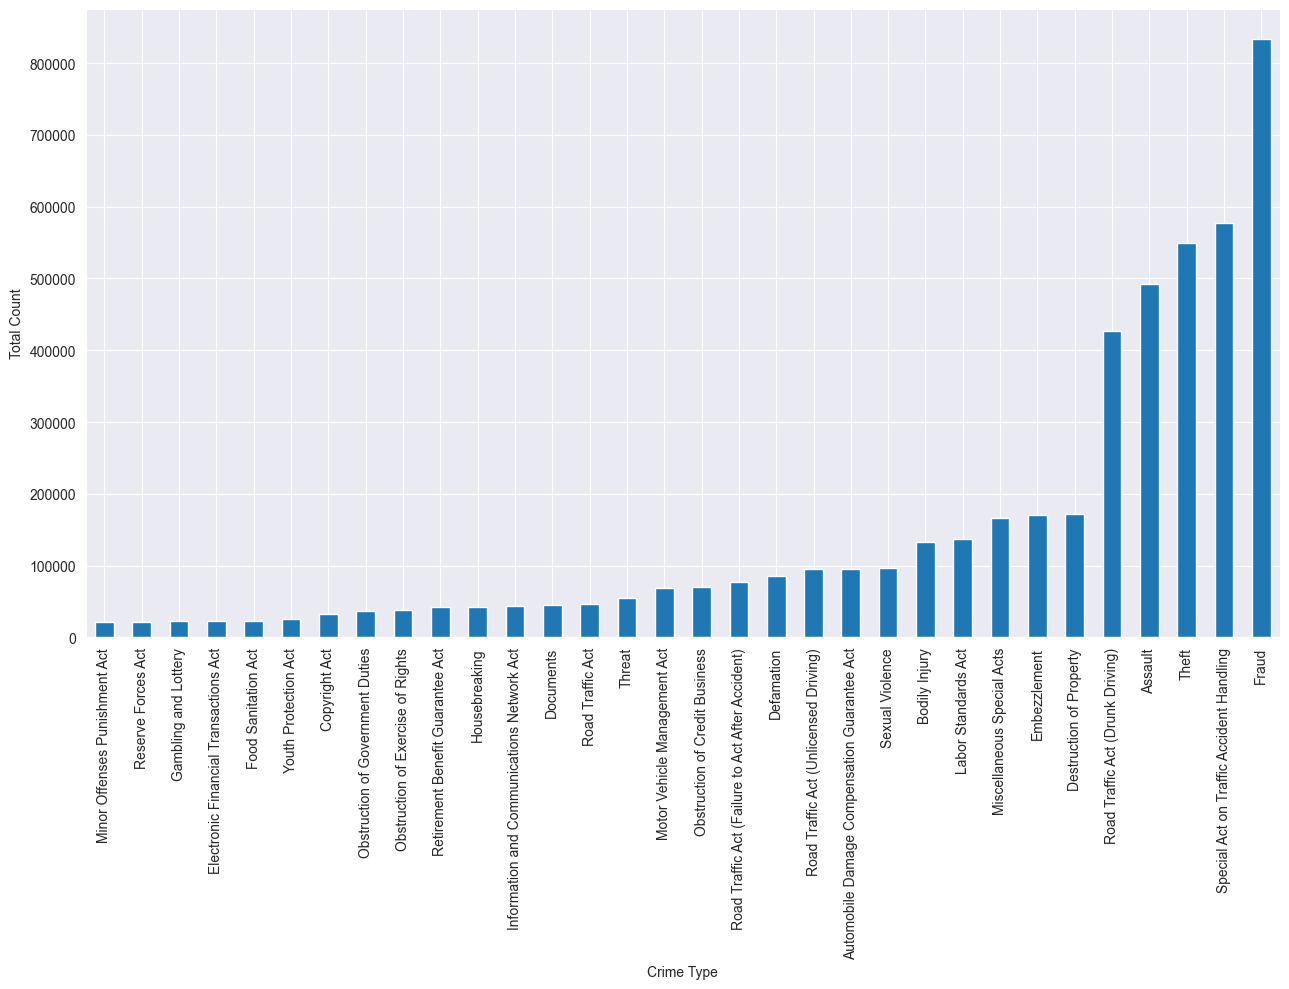

In [20]:
#visualize number of crimes per types in bar plot.
total_crimes = df_crime.drop(columns=['year', 'month']).sum()
total_crimes = total_crimes.sort_values()

# Plot the total crimes for each type
plt.figure(figsize=(13, 10))
total_crimes.plot(kind='bar')
plt.xlabel('Crime Type')
plt.ylabel('Total Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [21]:
df_crime_compare = df_crime.drop(columns=['year', 'month'])
#print(df_crime_compare.columns)
max_df_crime = df_crime_compare.max().max()
max_df_crime

28432

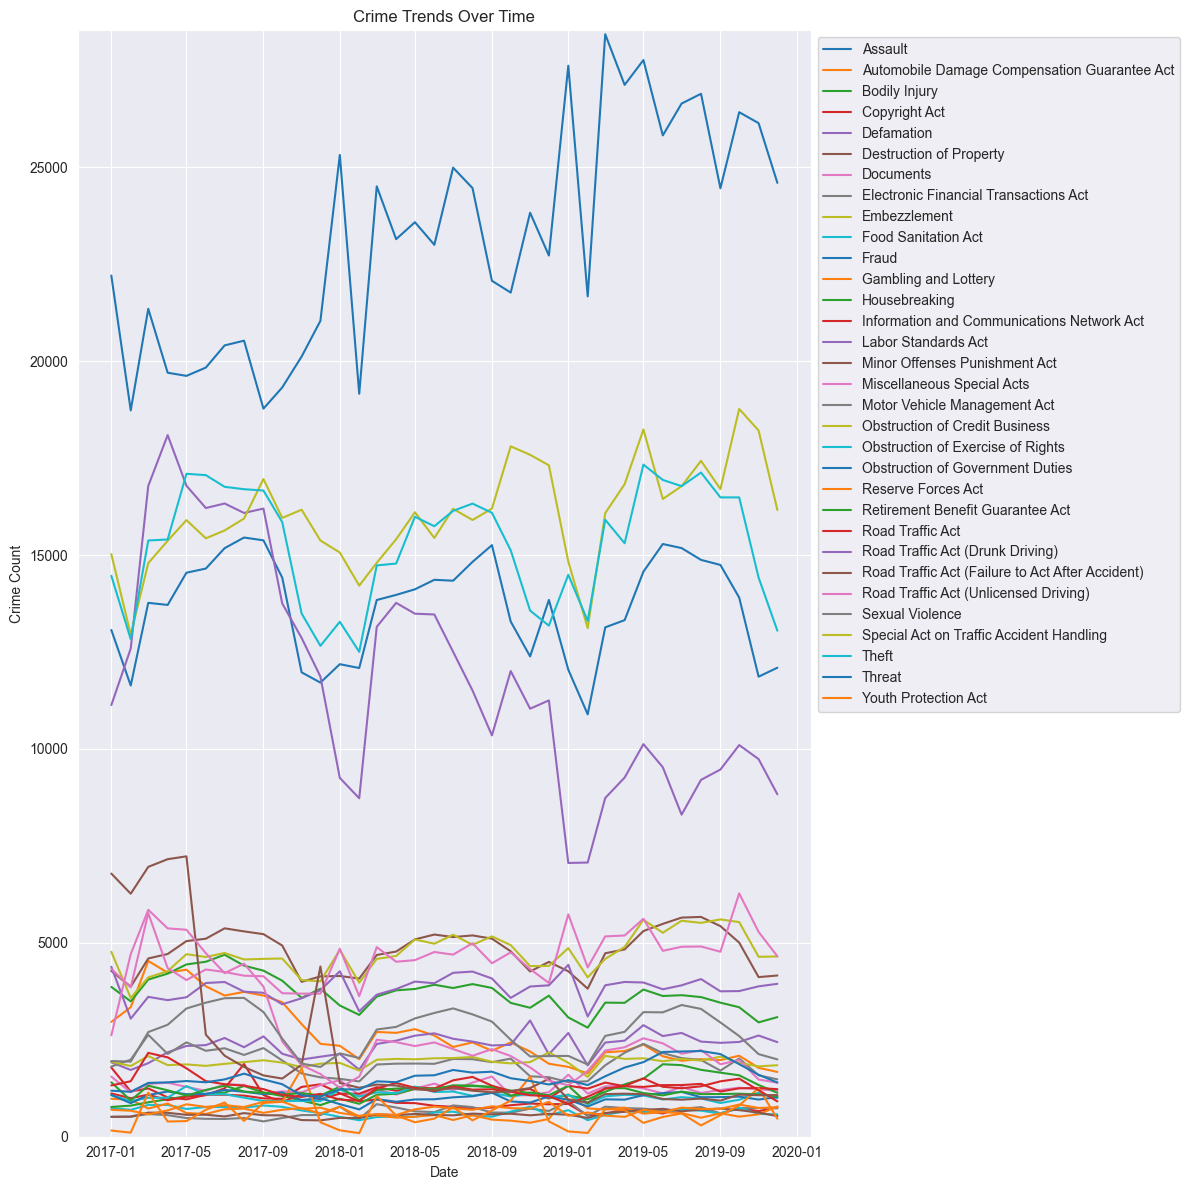

In [22]:
# create date
df_crime_temp = df_crime.copy()
df_crime_temp['date'] = pd.to_datetime(df_crime_temp[['year', 'month']].assign(DAY=1))

plt.figure(figsize=(12, 12))

for crime in df_crime_temp.columns[2:-1]:  # Assuming the crime types start from the 3rd column
    plt.plot(df_crime_temp['date'], df_crime_temp[crime], label=crime)

plt.title('Crime Trends Over Time')

plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.ylim(0, max_df_crime + 100)
plt.show()

### Linear Regression

In [23]:
#merge crime and climate dfs together
df_climate = df_climate_merged.copy()
df_merged = pd.merge(df_crime, df_climate, on=['year', 'month'], how='inner')

climate_predictors = ["avg_temp", "avg_temp_diff", "avg_humidity", "sun_exposure_percent", "avg_wind_speed_ms", "rainfall_mm"]

# scale climate
scaler_climate = StandardScaler()
df_merged[climate_predictors] = scaler_climate.fit_transform(df_merged[climate_predictors])

# we may use this scaler later for reverting back
climate_scaler = scaler_climate

# scale crime
crime_columns = df_crime.columns.difference(['year', 'month'])

scaler_crime = StandardScaler()
df_merged[crime_columns] = scaler_crime.fit_transform(df_merged[crime_columns])

crime_scaler = scaler_crime


split the data for testing

In [24]:

n_total = len(df_merged)
n_test = 3
n_train = n_total - n_test

df_train = df_merged.iloc[:n_train]
df_test = df_merged.iloc[n_train:]
X_train = df_train[climate_predictors]
X_full = df_merged[climate_predictors]


#### Linear Regression

In [25]:
model_results = {}

for crime_type in crime_columns:
    y_train = df_train[crime_type]

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict full
    y_pred_full = model.predict(X_full)

    # Predict last 3 months
    y_pred_test = y_pred_full[n_train:]
    y_true_test = df_test[crime_type]

    # Save
    model_results[crime_type] = {
        'model': model,
        'predictions_full': y_pred_full,
        'predictions_test': y_pred_test,
        'coef': model.coef_,
        'mse': mean_squared_error(y_true_test, y_pred_test),
        'sum_error': (y_true_test - y_pred_test).sum()
    }

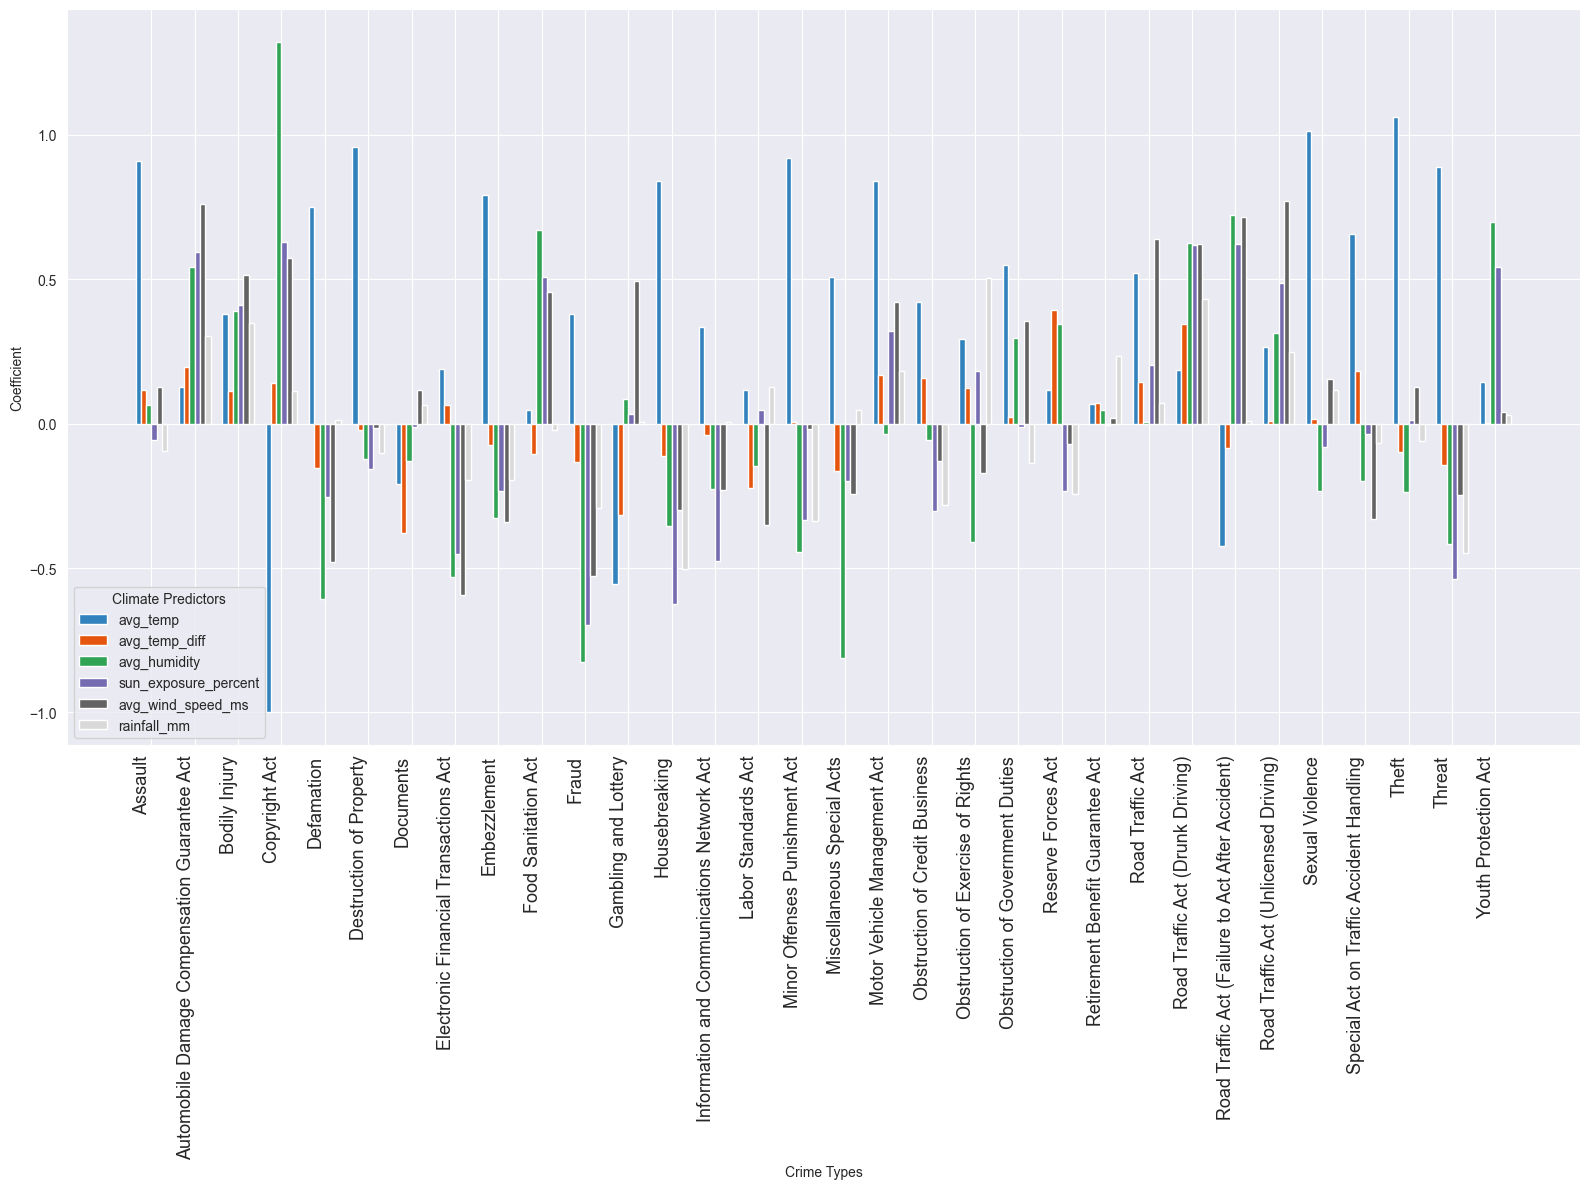

In [26]:
crime_types = list(model_results.keys())

fig, ax = plt.subplots(figsize=(16, 12))

colors = plt.cm.tab20c(np.linspace(0, 1, len(climate_predictors)))

# Automatically adjust bar width
bar_width = 3.9 / len(crime_types)
index = np.arange(len(crime_types))
gap_between_crimes = 0.5
x_offset = gap_between_crimes

#plot the coefficients for each crime type
for i, crime_type in enumerate(crime_types):
    coef = model_results[crime_type]['coef']

    for j, predictor in enumerate(climate_predictors):
        ax.bar(index[i] + j * bar_width + x_offset, coef[j], bar_width, label=predictor if i == 0 else "", color=colors[j])

ax.set_xlabel('Crime Types')
ax.set_ylabel('Coefficient')

ax.set_xticks(index + x_offset + (bar_width * (len(climate_predictors) - 1)) / 2)
ax.set_xticklabels(crime_types, rotation=90, ha='right', fontsize=13)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Climate Predictors')

plt.tight_layout()
plt.show()


### Anova modeling

In [27]:
# ARMA Modeling

arma_results = {}

df_arma = df_merged.copy()
df_arma['date'] = pd.to_datetime(dict(year=df_arma['year'], month=df_arma['month'], day=1))
df_arma = df_arma.sort_values(by='date').set_index('date')

for crime_type in crime_columns:
    try:
        ts_data = df_arma[crime_type].iloc[:n_train].dropna()

        model = ARIMA(ts_data, order=(2, 0, 2))
        fitted_model = model.fit()
        predictions_full = fitted_model.predict(start=0, end=n_total-1)
        predictions_test = predictions_full.iloc[n_train:]
        ts_test = df_arma[crime_type].iloc[n_train:]

        pred_df = predictions_full.to_frame(name='arma_prediction')
        pred_df['year'] = pred_df.index.year
        pred_df['month'] = pred_df.index.month
        pred_df = pred_df.reset_index()

        # Save
        arma_results[crime_type] = {
            'model': fitted_model,
            'predictions_full': pred_df,
            'predictions_test': predictions_test,
            'mse': mean_squared_error(ts_test, predictions_test),
            'sum_error': (ts_test - predictions_test).sum()
        }
    except Exception as e:
        print(f"ARMA FAILED: {crime_type}, error: {e}")


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib

### BSTS modeling
done using pymc v5

In [28]:
# BSTS modeling

bsts_results = {}

def fit_bsts_model(crime_type, df_train_input, df_full_input, predictors):
    y_train = df_train_input[crime_type].values
    X_train = df_train_input[predictors].values
    X_full = df_full_input[predictors].values
    n_train = X_train.shape[0]
    n_full = X_full.shape[0]
    k = X_train.shape[1]

    with pm.Model() as model:
        level = pm.GaussianRandomWalk('level', sigma=1.0, shape=n_train)
        beta = pm.Normal('beta', mu=0, sigma=1, shape=k)
        regression_part = pm.math.dot(X_train, beta)
        sigma = pm.HalfNormal('sigma', sigma=1)

        mu = level + regression_part

        y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)

        idata = pm.sample(1000, tune=1000, chains=2, target_accept=0.95, return_inferencedata=True)

    beta_mean = idata.posterior["beta"].mean(dim=("chain", "draw")).values
    intercept_mean = idata.posterior["level"].mean(dim=("chain", "draw")).values

    reg_pred_full = np.dot(X_full, beta_mean)

    last_level = intercept_mean[-1]
    level_extension = np.full(n_full - n_train, last_level)
    full_level = np.concatenate([intercept_mean, level_extension])

    y_pred_full = reg_pred_full + full_level

    return y_pred_full

for crime_type in crime_columns:
    print(f"Fitting BSTS for {crime_type}...")
    try:
        y_pred_full = fit_bsts_model(crime_type, df_train, df_merged, climate_predictors)

        y_true_test = df_test[crime_type]
        y_pred_test = y_pred_full[n_train:]

        bsts_results[crime_type] = {
            'predictions_full': y_pred_full,
            'predictions_test': y_pred_test,
            'mse': mean_squared_error(y_true_test, y_pred_test),
            'sum_error': (y_true_test - y_pred_test).sum()
        }
    except Exception as e:
        print(f"BSTS FAILED: {crime_type}, error: {e}")


Fitting BSTS for Assault...


D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pytensor\link\c\cmodule.py:2959: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-tes

Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 47 seconds.
There were 997 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


Fitting BSTS for Automobile Damage Compensation Guarantee Act...


...

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 63 seconds.
There were 47 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
D:\data_analytics_and_ai_project\env\ISYE6720_HW\Lib\site-packages\pymc\distributions\timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


Fitting BSTS for Youth Protection Act...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [level, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 26 seconds.
There were 209 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [29]:
summary_list = []

for crime_type in crime_columns:
    summary_list.append({
        "Crime Type": crime_type,
        "Method": "Linear Regression",
        "MSE": model_results[crime_type]['mse'],
        "Sum of Errors": model_results[crime_type]['sum_error']
    })

    summary_list.append({
        "Crime Type": crime_type,
        "Method": "ARMA",
        "MSE": arma_results[crime_type]['mse'],
        "Sum of Errors": arma_results[crime_type]['sum_error']
    })

    summary_list.append({
        "Crime Type": crime_type,
        "Method": "BSTS",
        "MSE": bsts_results[crime_type]['mse'],
        "Sum of Errors": bsts_results[crime_type]['sum_error']
    })

df_comparison = pd.DataFrame(summary_list)


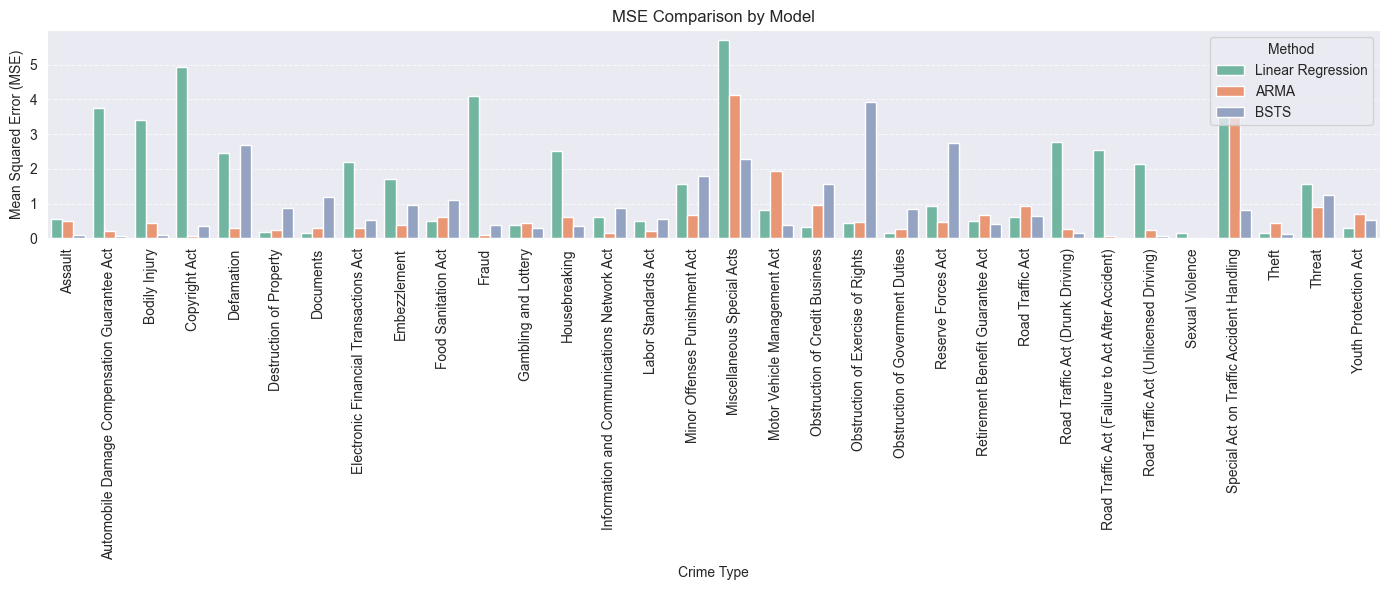

In [30]:
# Plot MSE comparison for 3-month CV
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_comparison,
    x='Crime Type',
    y='MSE',
    hue='Method',
    palette='Set2'
)
plt.title('MSE Comparison by Model')
plt.xlabel('Crime Type')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=90, fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [31]:
#df_comparison.to_csv("model_comparison_summary.csv", index=False)
df_comparison

,Crime Type,Method,MSE,Sum of Errors
0,Assault,Linear Regression,0.554392,-1.893724
1,Assault,ARMA,0.495403,-1.675699
2,Assault,BSTS,0.085031,0.295010
3,Automobile Damage Compensation Guarantee Act,Linear Regression,3.745280,-5.653182
4,Automobile Damage Compensation Guarantee Act,ARMA,0.197947,-1.053525
...,...,...,...,...
91,Threat,ARMA,0.892557,-2.615953
92,Threat,BSTS,1.236713,-3.131312
93,Youth Protection Act,Linear Regression,0.288572,1.291507
94,Youth Protection Act,ARMA,0.709715,2.295545


In [32]:
comparison_summary = []

for crime_type in crime_columns:
    mse_reg = model_results[crime_type]['mse']
    mse_anova = arma_results[crime_type]['mse']
    mse_bsts = bsts_results[crime_type]['mse']

    mse_diff = max(mse_reg, mse_anova, mse_bsts) - min(mse_reg, mse_anova, mse_bsts)

    comparison_summary.append({
        'crime_type': crime_type,
        'mse_regression': mse_reg,
        'mse_anova': mse_anova,
        'mse_bsts': mse_bsts,
        'mse_range': mse_diff
    })

df_mse_summary = pd.DataFrame(comparison_summary)

# top 5 and bottom 5 crime types based on MSE
df_top5 = df_mse_summary.sort_values(by='mse_range', ascending=False).head(5)
df_bottom5 = df_mse_summary.sort_values(by='mse_range', ascending=True).head(5)

# merge month and year for visualization
x_labels = df_merged["year"].astype(str) + '-' + df_merged["month"].astype(str).str.zfill(2)


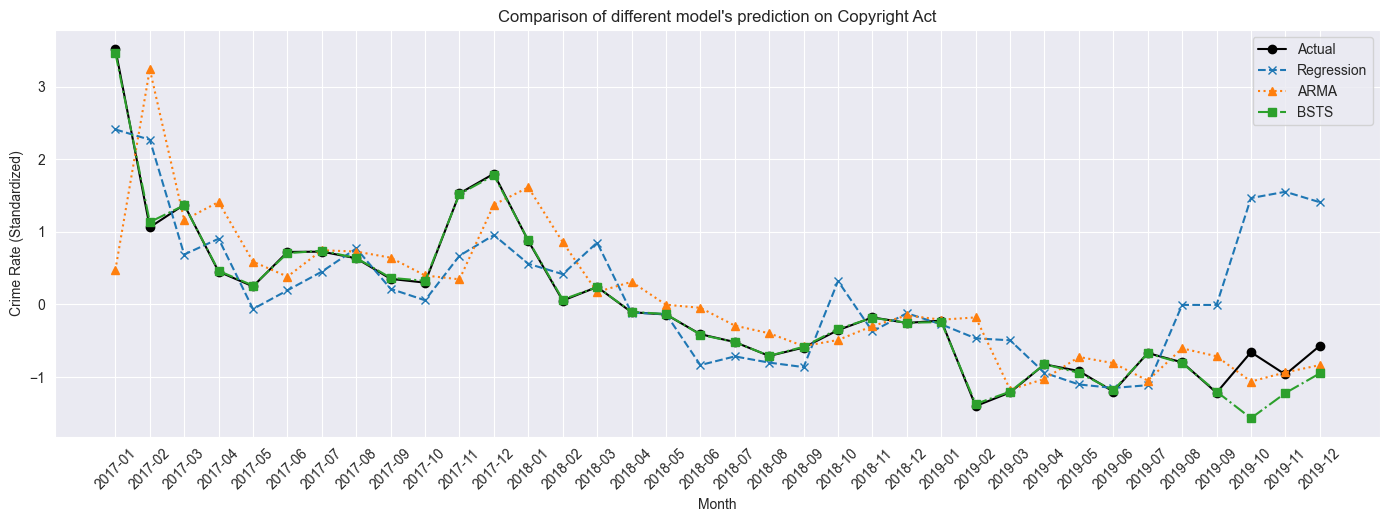

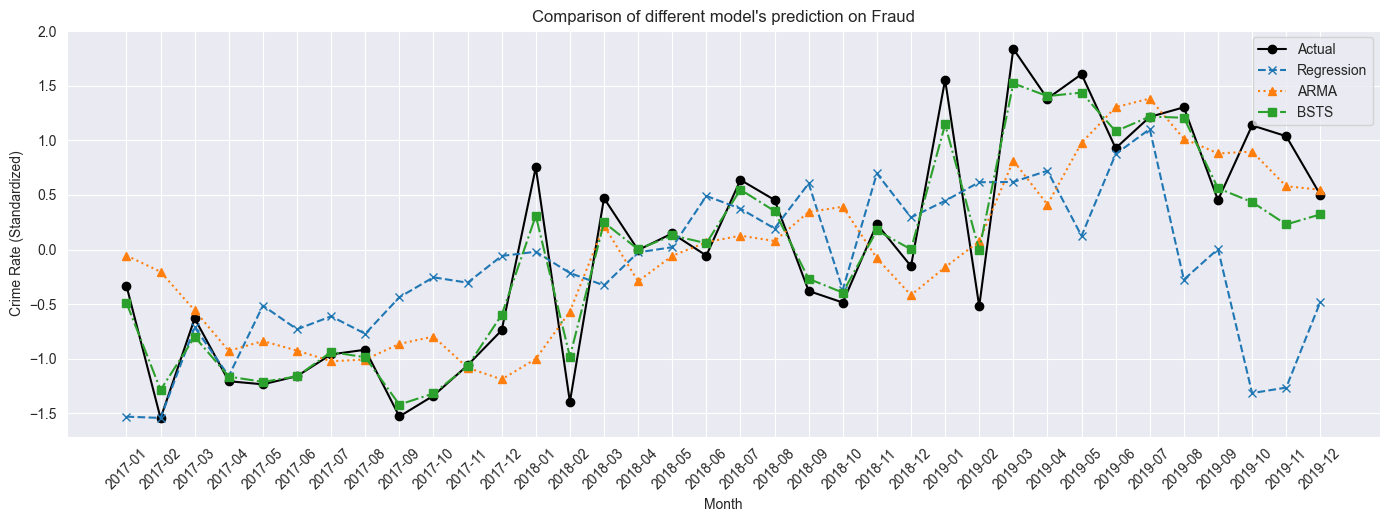

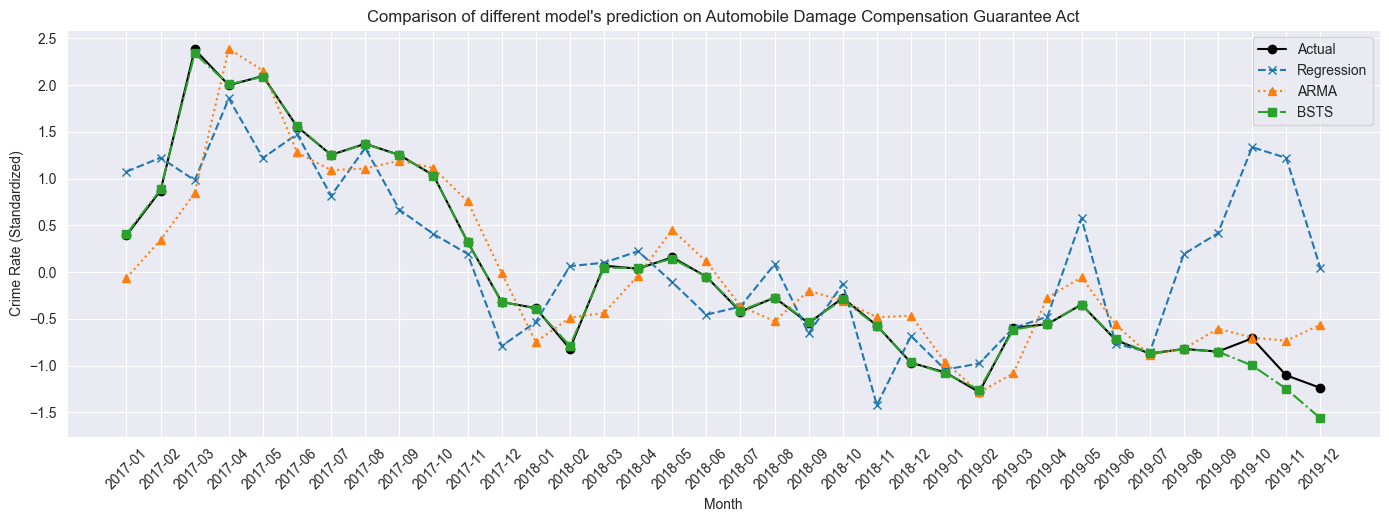

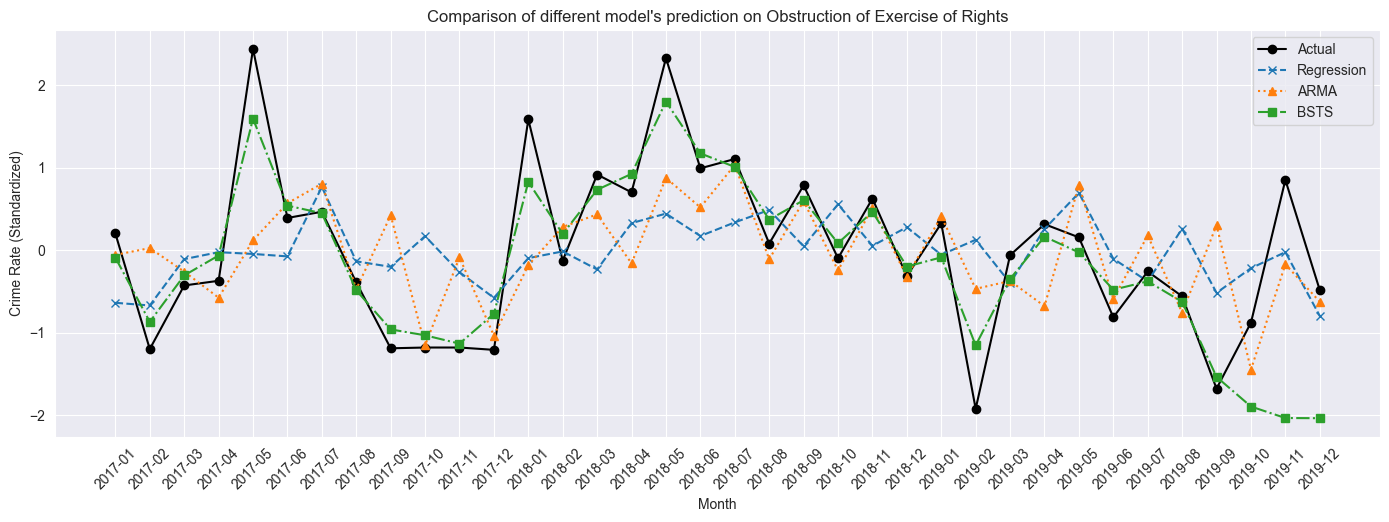

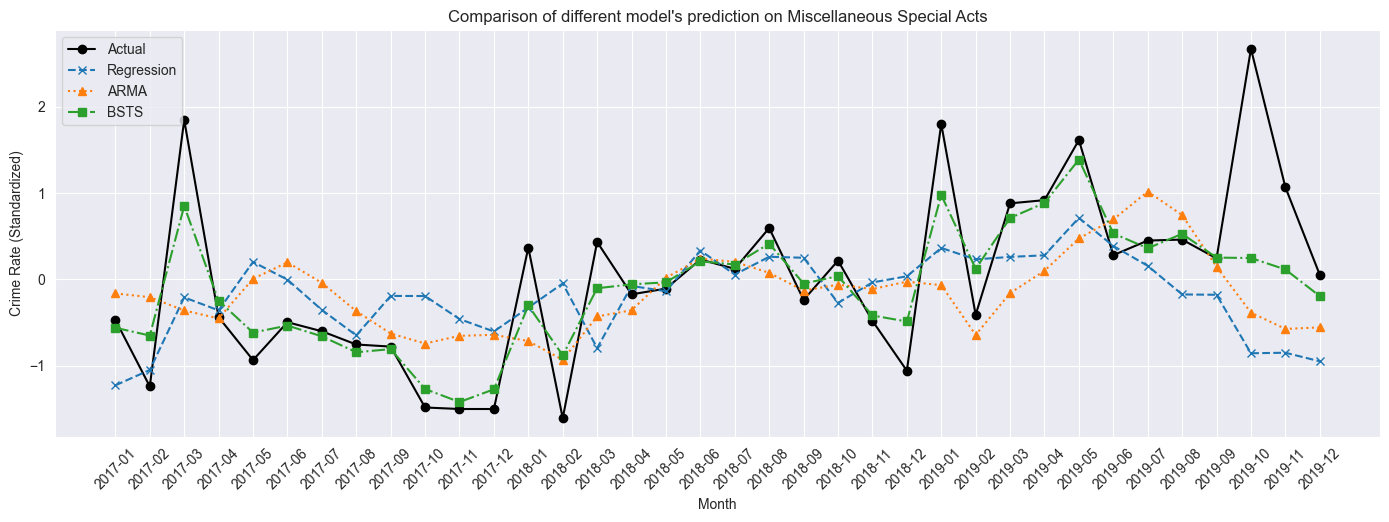

In [33]:
x_labels = df_merged["year"].astype(str) + '-' + df_merged["month"].astype(str).str.zfill(2)

# Plot for top 5
for crime_type in df_top5['crime_type']:
    actual = df_merged[crime_type].values
    pred_reg = model_results[crime_type]['predictions_full']
    pred_arma = arma_results[crime_type]['predictions_full']["arma_prediction"].values
    pred_bsts = bsts_results[crime_type]['predictions_full']

    plt.figure(figsize=(14, 5))
    plt.plot(actual, label='Actual', marker='o', color='black')
    plt.plot(pred_reg, label='Regression', linestyle='--', marker='x')
    plt.plot(pred_arma, label='ARMA', linestyle=':', marker='^')
    plt.plot(pred_bsts, label='BSTS', linestyle='-.', marker='s')

    plt.title(f"Comparison of different model's prediction on {crime_type}")
    plt.xlabel("Month")
    plt.ylabel("Crime Rate (Standardized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)
    plt.show()


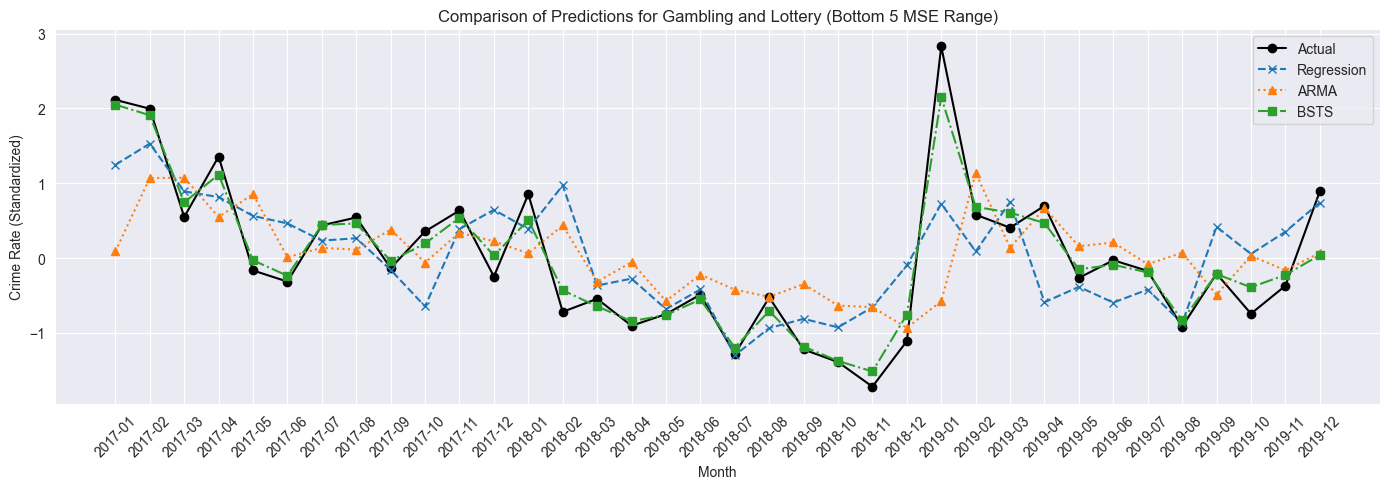

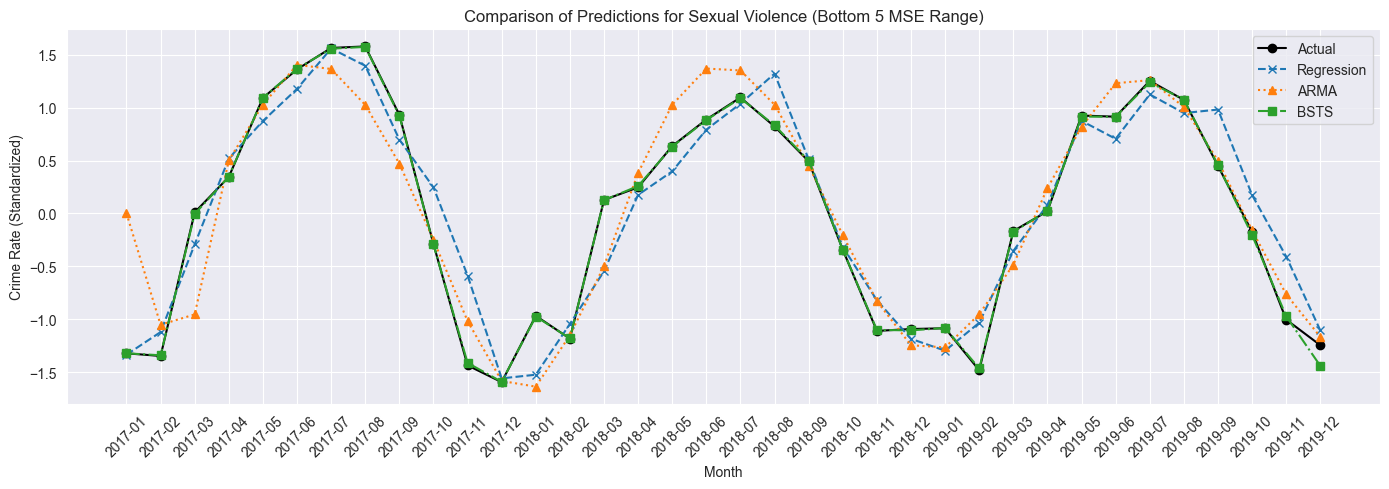

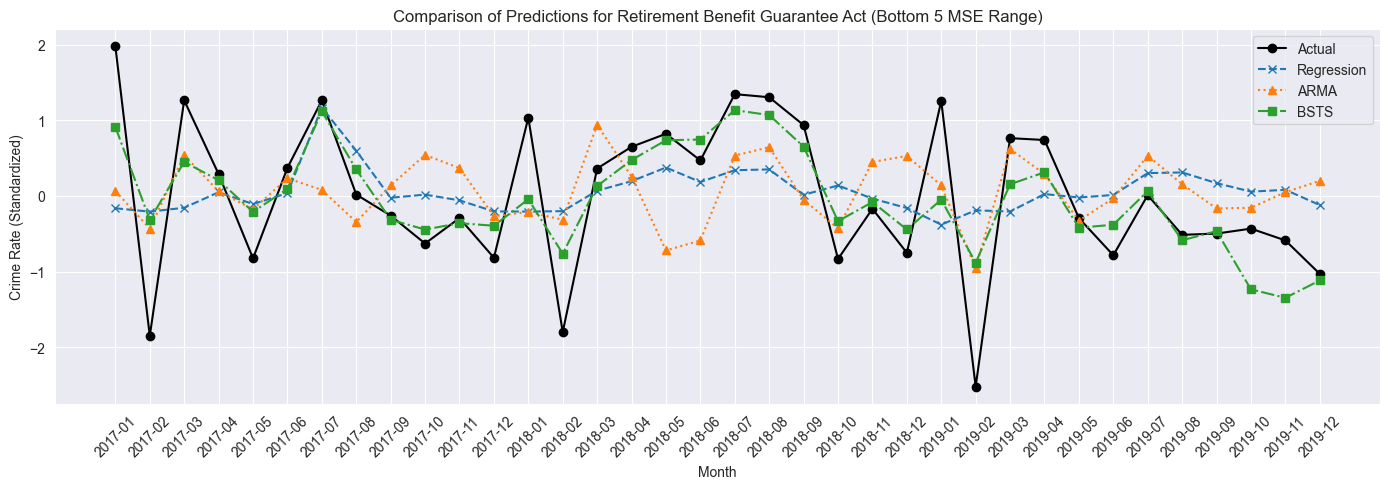

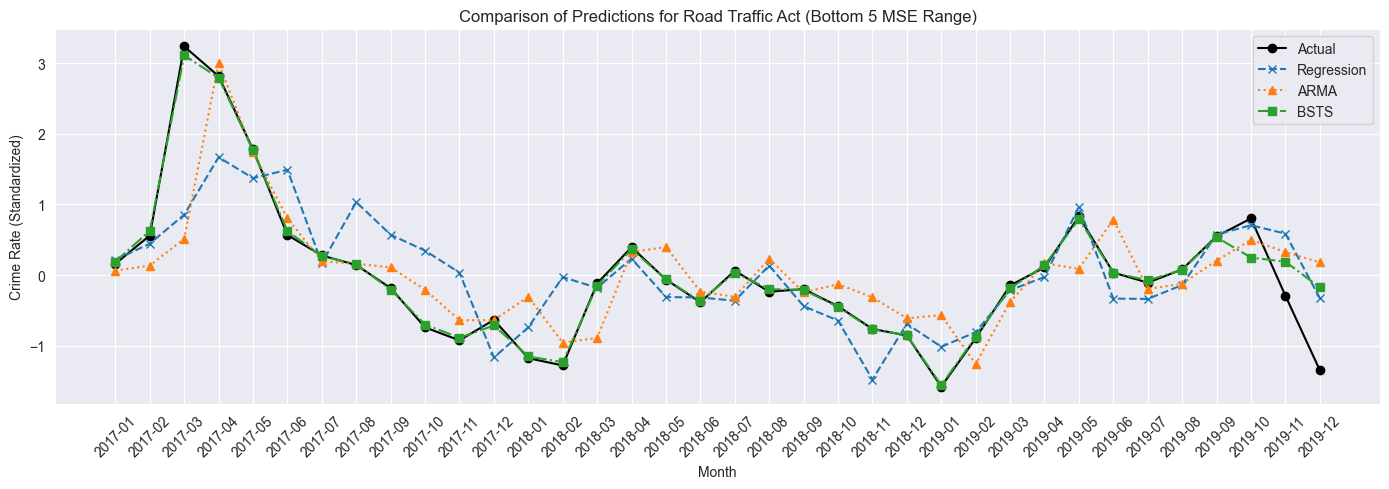

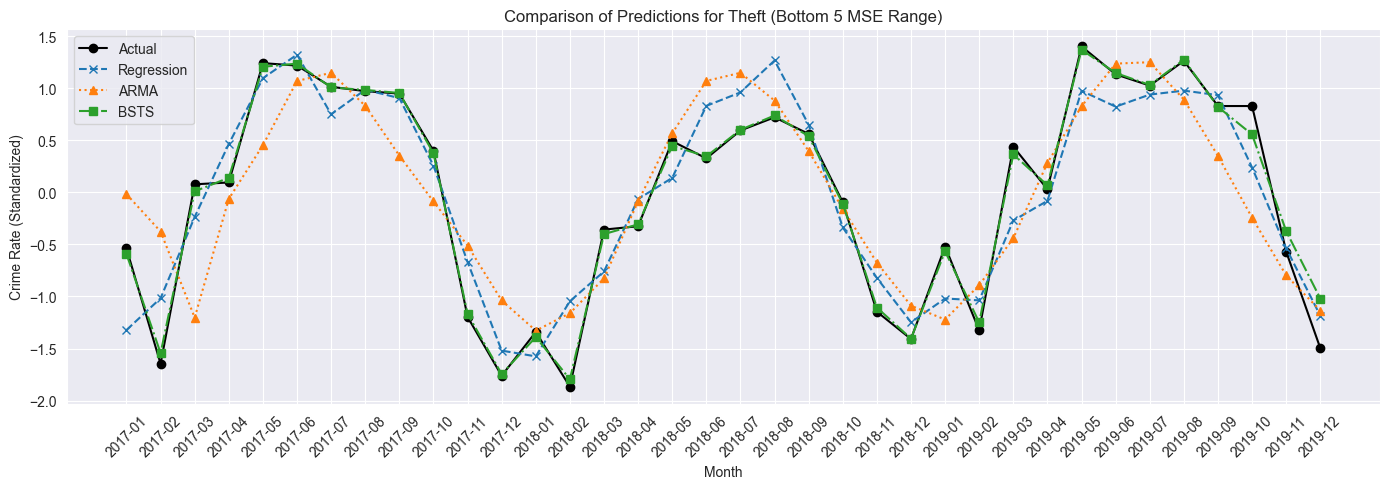

In [34]:
for crime_type in df_bottom5['crime_type']:
    actual = df_merged[crime_type].values
    pred_reg = model_results[crime_type]['predictions_full']
    pred_arma = arma_results[crime_type]['predictions_full']["arma_prediction"].values
    pred_bsts = bsts_results[crime_type]['predictions_full']

    plt.figure(figsize=(14, 5))
    plt.plot(actual, label='Actual', marker='o', color='black')
    plt.plot(pred_reg, label='Regression', linestyle='--', marker='x')
    plt.plot(pred_arma, label='ARMA', linestyle=':', marker='^')
    plt.plot(pred_bsts, label='BSTS', linestyle='-.', marker='s')

    plt.title(f"Comparison of Predictions for {crime_type} (Bottom 5 MSE Range)")
    plt.xlabel("Month")
    plt.ylabel("Crime Rate (Standardized)")
    plt.legend()
    plt.grid(True)
    plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)
    plt.tight_layout()
    plt.show()


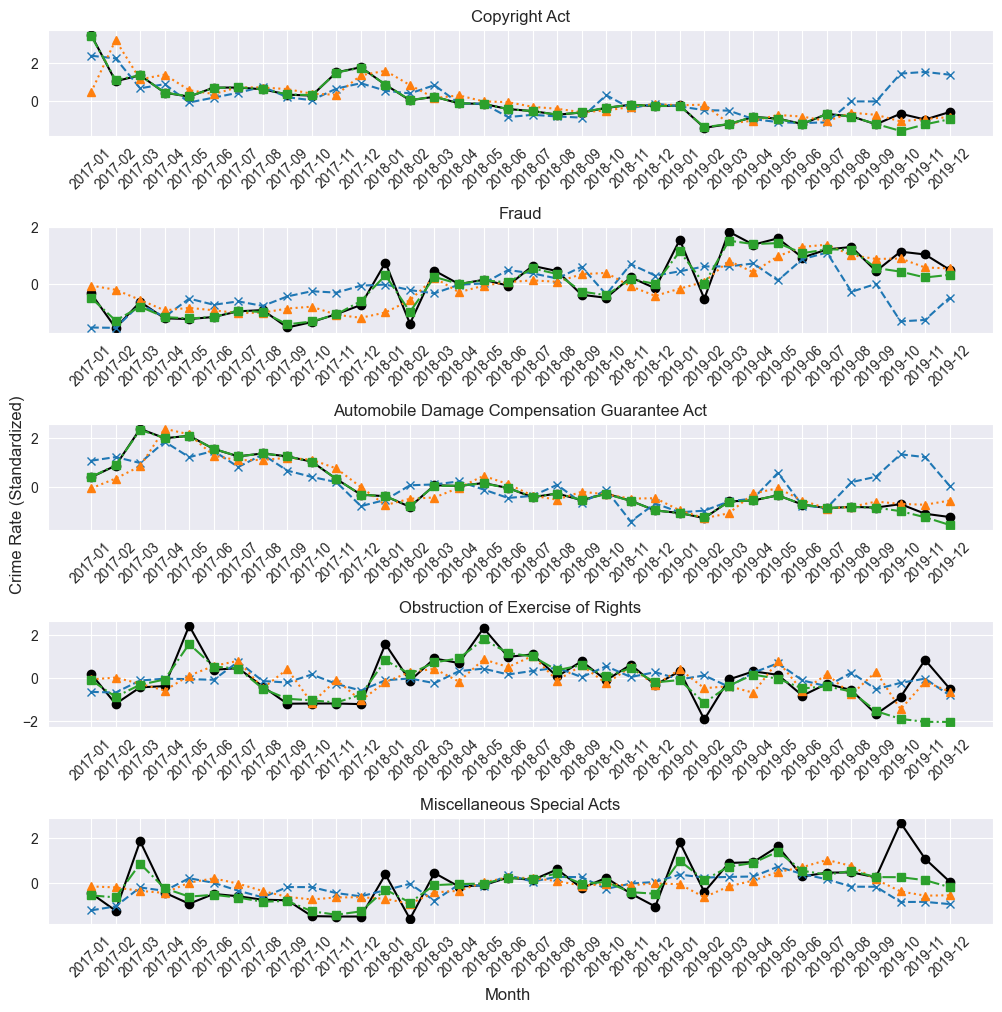

In [35]:
plt.figure(figsize=(10, 10))

for idx, crime_type in enumerate(df_top5['crime_type']):
    actual = df_merged[crime_type].values
    pred_reg = model_results[crime_type]['predictions_full']
    pred_arma = arma_results[crime_type]['predictions_full']["arma_prediction"].values
    pred_bsts = bsts_results[crime_type]['predictions_full']

    plt.subplot(5, 1, idx + 1)
    plt.plot(actual, label='Actual', marker='o', color='black')
    plt.plot(pred_reg, label='Regression', linestyle='--', marker='x')
    plt.plot(pred_arma, label='ARMA', linestyle=':', marker='^')
    plt.plot(pred_bsts, label='BSTS', linestyle='-.', marker='s')

    plt.title(f"{crime_type}")
    # plt.xlabel("Month")
    # plt.ylabel("Crime Rate (Standardized)")
    plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)
    plt.grid(True)

plt.figtext(0.5, 0.0, 'Month', ha='center', va='center', fontsize=12)
plt.figtext(0.01, 0.5, 'Crime Rate (Standardized)', ha='center', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.suptitle('Least Predictable Crimes', fontsize=18, y=1.02)

plt.show()

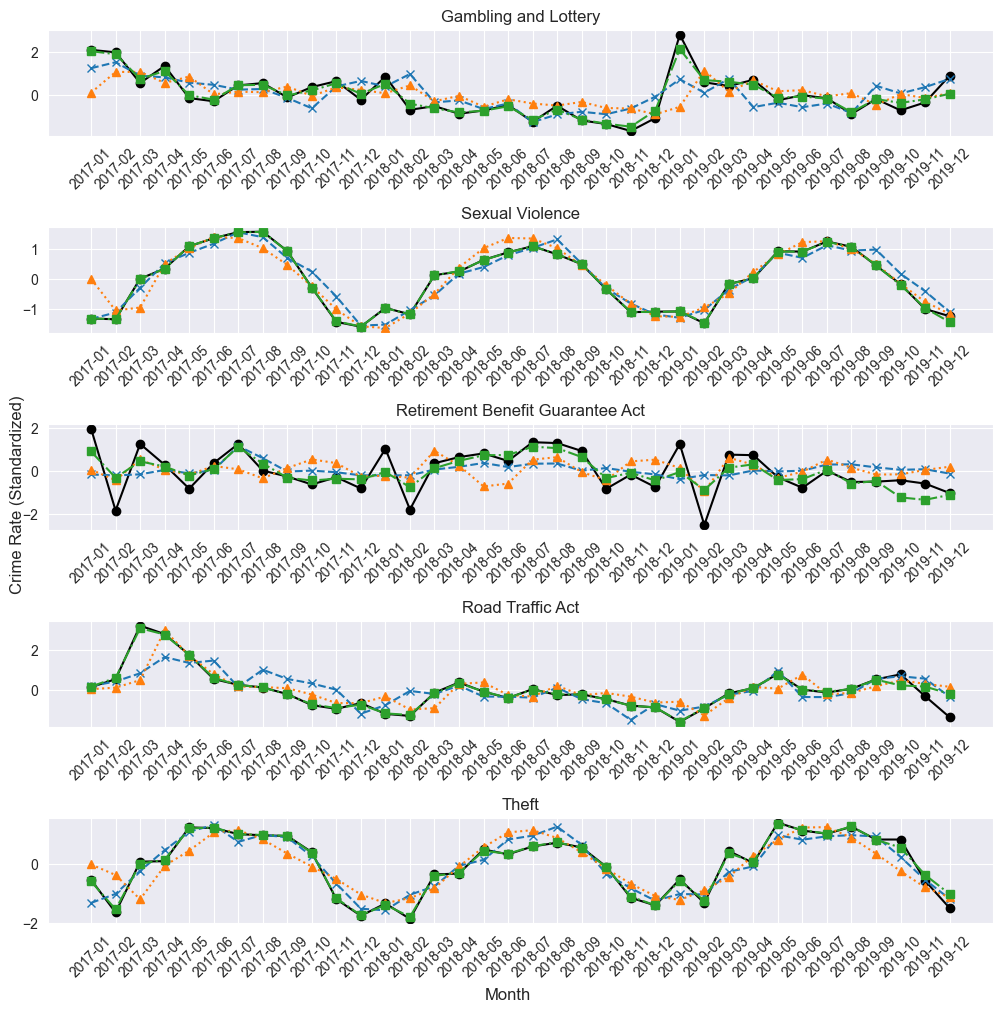

In [36]:
plt.figure(figsize=(10, 10))

for idx, crime_type in enumerate(df_bottom5['crime_type']):
    actual = df_merged[crime_type].values
    pred_reg = model_results[crime_type]['predictions_full']
    pred_arma = arma_results[crime_type]['predictions_full']["arma_prediction"].values
    pred_bsts = bsts_results[crime_type]['predictions_full']

    plt.subplot(5, 1, idx + 1)  # 5 rows, 1 column for Bottom 5
    plt.plot(actual, label='Actual', marker='o', color='black')
    plt.plot(pred_reg, label='Regression', linestyle='--', marker='x')
    plt.plot(pred_arma, label='ARMA', linestyle=':', marker='^')
    plt.plot(pred_bsts, label='BSTS', linestyle='-.', marker='s')

    plt.title(f"{crime_type}")
    plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45)
    plt.grid(True)

plt.figtext(0.5, 0.0, 'Month', ha='center', va='center', fontsize=12)
plt.figtext(0.01, 0.5, 'Crime Rate (Standardized)', ha='center', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.suptitle('Most Predictable Crimes', fontsize=18, y=1.02)

plt.show()